# Statistical Pairs Trading — UA Quant Finance Club

**Hypothesis:** Mean-reverting spread between cointegrated peers in the same sector.

**Data:** Real adjusted closes via `data.fetcher` (cached Yahoo Finance pulls; see `config.yaml`).

**What “good” testing means here**

1. **Walk-forward hedge ratio** — `backtest_pair_rolling_beta` re-estimates the OLS $\beta$ on a **past-only** window every `rebalance_every` sessions, so the OOS period does not reuse a single in-sample $\beta$.
2. **Crossing entries** — `entry_mode: cross` enters when $z$ **crosses** $\pm\text{entry\_z}$, not merely when the level is extreme (reduces spurious trades).
3. **Optional Bonferroni** — `use_bonferroni` tightens the Engle–Granger cutoff by the number of pair tests (often **no** pairs; treat as a research switch).
4. **Half-life filter** — `max_half_life_days` drops slow mean-reversion (optional).
5. **Train/test split** — `walk_forward_coint_then_test` runs the **cointegration scan on train only**, then evaluates on **test** with the **train** $\beta$ (no pair selection on the test window).

**Risk:** Cointegration breaks; costs/slippage; simulator-only execution.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from utils.config import CONFIG


def _plt_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f8f8",
        "axes.grid": True,
        "grid.alpha": 0.4,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    })

_plt_style()
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print("Loaded CONFIG.")


Loaded CONFIG.


In [2]:
from data.fetcher import fetch
from data.universe import get_all_tickers

from alphas.pairs_trading.evaluation import count_pair_tests
from alphas.pairs_trading.strategy import build_universe_for_scan

bt = CONFIG["backtest"]
UNIVERSE_CFG = CONFIG["universe"]
universe = build_universe_for_scan(UNIVERSE_CFG)
ALL_TICKERS = get_all_tickers()

start_full = bt["start_date"]
end_full = bt.get("oos_end", "2024-12-31")

raw = fetch(ALL_TICKERS, start_full, end_full)
print(raw.shape, list(raw.columns)[:8], "...")
prices_in = raw.loc[bt["start_date"] : bt["end_date"]]
prices_out = raw.loc[bt["oos_start"] : end_full]
# Honest train/test: scan pairs on 2021–2022 only; evaluate 2023 (see walk-forward section)
train_end = "2022-12-31"
test_start = "2023-01-01"
prices_train = raw.loc[bt["start_date"] : train_end]
prices_test = raw.loc[test_start : bt["end_date"]]
print("n_pair_tests (for Bonferroni):", count_pair_tests(universe, prices_in))


(1004, 25) ['JPM', 'BAC', 'GS', 'MS', 'WFC', 'MSFT', 'AAPL', 'GOOGL'] ...
n_pair_tests (for Bonferroni): 50


Pairs tested: 50, cointegrated: 2 (Bonferroni=off)
   sector ticker1 ticker2  coint_p   adf_p    beta  half_life_days  cointegrated
0  Energy     COP     EOG   0.0187  0.0043  1.0228           14.46          True
1   Semis    INTC      MU   0.0487  0.0130  0.7692           23.30          True


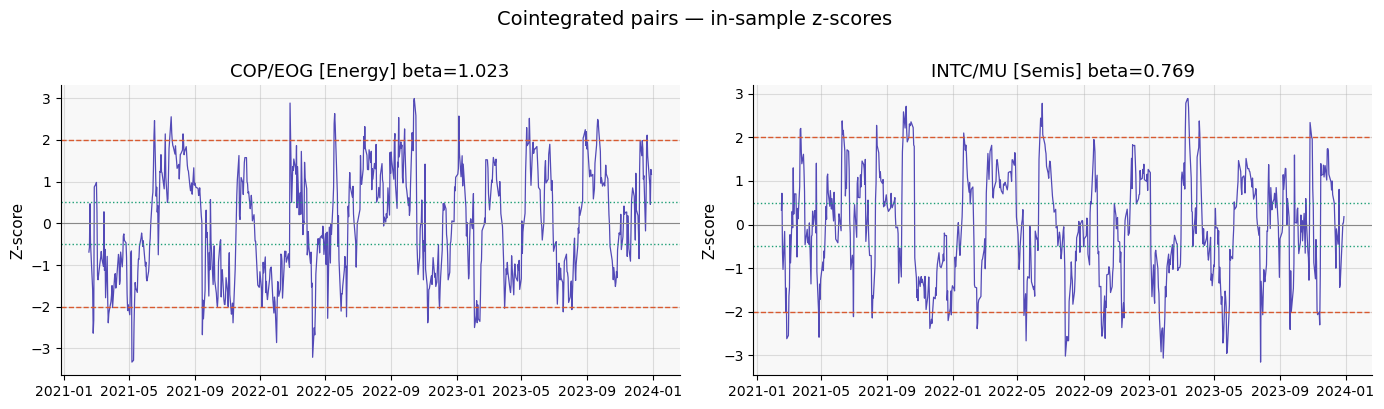

In [3]:
from alphas.pairs_trading.strategy import compute_spread, run_coint_scan

pairs_cfg = CONFIG["pairs_trading"]
p_thresh = pairs_cfg["coint_p_threshold"]
n_tests = count_pair_tests(universe, prices_in)
use_bonf = bool(pairs_cfg.get("use_bonferroni", False))
mhl = pairs_cfg.get("max_half_life_days")
mhl_f = float(mhl) if mhl is not None else None

scan = run_coint_scan(
    prices_in,
    universe,
    p_thresh,
    n_total_tests=n_tests if use_bonf else None,
    max_half_life_days=mhl_f,
)
coint_pairs = scan[scan["cointegrated"]].reset_index(drop=True)
print(f"Pairs tested: {len(scan)}, cointegrated: {len(coint_pairs)} (Bonferroni={'on' if use_bonf else 'off'})")
print(coint_pairs.head())

n = len(coint_pairs)
if n == 0:
    print("No pairs — try use_bonferroni: false, raise max_half_life_days, or relax coint_p_threshold.")
else:
    cols = min(2, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = np.array(axes).flatten()
    zw = pairs_cfg["zscore_window"]
    ez = pairs_cfg["entry_z"]
    exz = pairs_cfg["exit_z"]
    for i, row in coint_pairs.iterrows():
        t1, t2, beta = row["ticker1"], row["ticker2"], float(row["beta"])
        _, zscore = compute_spread(prices_in, t1, t2, beta, zw)
        ax = axes[i]
        ax.plot(zscore, color="#534AB7", linewidth=0.9, label="Z-score")
        ax.axhline(ez, color="#D85A30", linestyle="--", linewidth=1)
        ax.axhline(-ez, color="#D85A30", linestyle="--", linewidth=1)
        ax.axhline(0, color="#888", linewidth=0.8)
        ax.axhline(exz, color="#1D9E75", linestyle=":", linewidth=1)
        ax.axhline(-exz, color="#1D9E75", linestyle=":", linewidth=1)
        ax.set_title(f"{t1}/{t2} [{row['sector']}] beta={beta:.3f}")
        ax.set_ylabel("Z-score")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Cointegrated pairs — in-sample z-scores", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


In [4]:
from alphas.pairs_trading.strategy import backtest_pair, backtest_pair_rolling_beta

pairs_cfg = CONFIG["pairs_trading"]
bt = CONFIG["backtest"]
entry_mode = str(pairs_cfg.get("entry_mode", "cross"))

all_trades_roll = []
all_equity_roll = {}
all_trades_static = []
all_equity_static = {}

for _, row in coint_pairs.iterrows():
    t1, t2 = row["ticker1"], row["ticker2"]
    beta = float(row["beta"])
    if t1 not in prices_in.columns or t2 not in prices_in.columns:
        continue
    tr_r, eq_r = backtest_pair_rolling_beta(
        prices_in,
        t1,
        t2,
        beta_lookback=int(pairs_cfg.get("beta_lookback", 252)),
        rebalance_every=int(pairs_cfg.get("rebalance_every", 21)),
        zscore_window=pairs_cfg["zscore_window"],
        entry_z=pairs_cfg["entry_z"],
        exit_z=pairs_cfg["exit_z"],
        stop_z=pairs_cfg["stop_z"],
        notional=float(bt["notional_per_trade"]),
        transaction_cost=float(bt["transaction_cost"]),
        entry_mode=entry_mode,
    )
    tr_s, eq_s = backtest_pair(
        prices_in,
        t1,
        t2,
        beta,
        zscore_window=pairs_cfg["zscore_window"],
        entry_z=pairs_cfg["entry_z"],
        exit_z=pairs_cfg["exit_z"],
        stop_z=pairs_cfg["stop_z"],
        notional=float(bt["notional_per_trade"]),
        transaction_cost=float(bt["transaction_cost"]),
        entry_mode=entry_mode,
    )
    label = f"{t1}/{t2}"
    if len(tr_r):
        tr_r = tr_r.copy()
        tr_r["pair"] = label
        all_trades_roll.append(tr_r)
        all_equity_roll[label] = eq_r
    if len(tr_s):
        tr_s = tr_s.copy()
        tr_s["pair"] = label
        all_trades_static.append(tr_s)
        all_equity_static[label] = eq_s

# Prefer rolling-beta results for downstream “portfolio” metrics
all_trades = all_trades_roll
all_equity = all_equity_roll

if all_trades:
    print("In-sample (rolling beta):", len(all_trades), "pair(s) with trades.")
    print("In-sample (static beta):", len(all_trades_static), "pair(s) with trades.")
else:
    print("No trades — adjust thresholds, entry_mode, or universe.")


In-sample (rolling beta): 2 pair(s) with trades.
In-sample (static beta): 2 pair(s) with trades.


In [5]:
from reports.metrics import (
    performance_summary,
    profit_factor,
    sharpe_ratio,
    sortino_ratio,
    win_rate,
    max_drawdown,
    calmar_ratio,
)

if not all_trades:
    print("No trades to score.")
else:
    combined_trades = pd.concat(all_trades, ignore_index=True)
    eq_sum = None
    for label, eq in all_equity.items():
        s = eq["equity"]
        eq_sum = s if eq_sum is None else eq_sum.add(s, fill_value=0)
    daily_ret = eq_sum.diff().fillna(0.0)
    print("=== In-sample: rolling hedge ratio (summed equity across pairs) ===")
    print("Sharpe:", sharpe_ratio(daily_ret))
    print("Sortino:", sortino_ratio(daily_ret))
    print("Max drawdown (fraction of peak):", max_drawdown(eq_sum))
    print("Calmar:", calmar_ratio(daily_ret))
    print("Win rate:", win_rate(combined_trades))
    print("Profit factor:", profit_factor(combined_trades))
    summ = performance_summary(eq_sum, combined_trades)
    for k, v in summ.items():
        print(f"{k}: {v}")


=== In-sample: rolling hedge ratio (summed equity across pairs) ===
Sharpe: -0.558244785866629
Sortino: -0.6161765433122779
Max drawdown (fraction of peak): -5.335256500908275
Calmar: nan
Win rate: 0.43478260869565216
Profit factor: 0.5635142715778082
sharpe_ratio: -0.5582
sortino_ratio: -0.6162
calmar_ratio: nan
max_drawdown: -5.335257
win_rate: 0.4348
profit_factor: 0.5635
avg_hold_days: 20.52
n_trades: 23


In [6]:
# Visualization: best pair by total net P&L (rolling-beta run)
if all_trades:
    combined_trades = pd.concat(all_trades, ignore_index=True)
    best_pair = combined_trades.groupby("pair")["net_pnl"].sum().idxmax()
    t1, t2 = best_pair.split("/")
    beta_row = coint_pairs[(coint_pairs["ticker1"] == t1) & (coint_pairs["ticker2"] == t2)]
    beta = float(beta_row["beta"].values[0]) if len(beta_row) else 1.0
    pairs_cfg = CONFIG["pairs_trading"]
    _, zscore = compute_spread(prices_in, t1, t2, beta, pairs_cfg["zscore_window"])
    trades_best = combined_trades[combined_trades["pair"] == best_pair]
    equity_best = all_equity[best_pair]

    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)
    ax1 = fig.add_subplot(gs[0, :])
    p1n = (prices_in[t1] / prices_in[t1].iloc[0]) * 100
    p2n = (prices_in[t2] / prices_in[t2].iloc[0]) * 100
    ax1.plot(p1n, label=t1, color="#534AB7")
    ax1.plot(p2n, label=t2, color="#D85A30")
    ax1.legend()
    ax1.set_title("Normalized prices (in-sample)")

    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(zscore, color="#534AB7", linewidth=0.9)
    ax2.axhline(pairs_cfg["entry_z"], color="#D85A30", linestyle="--")
    ax2.axhline(-pairs_cfg["entry_z"], color="#D85A30", linestyle="--")
    ax2.set_title("Z-score (static beta — illustration; entries use rolling beta in backtest)")
    ax3 = fig.add_subplot(gs[2, 0])
    equity_best["equity"].plot(ax=ax3, color="#534AB7")
    ax3.set_title("Cumulative P&L ($) — rolling beta")
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.hist(trades_best["net_pnl"], bins=15, color="#1D9E75", alpha=0.7)
    ax4.set_title("Trade P&L distribution")
    plt.suptitle(f"Deep dive: {best_pair}", fontsize=14)
    plt.show()
else:
    print("No trades to plot.")


In [7]:
# Out-of-sample: rolling beta (recommended) vs one static in-sample beta
bt = CONFIG["backtest"]
pairs_cfg = CONFIG["pairs_trading"]
oos_end = bt.get("oos_end", "2024-12-31")
entry_mode = str(pairs_cfg.get("entry_mode", "cross"))

if all_trades:
    combined_trades = pd.concat(all_trades, ignore_index=True)
    best_pair = combined_trades.groupby("pair")["net_pnl"].sum().idxmax()
    t1, t2 = best_pair.split("/")
    beta_row = coint_pairs[(coint_pairs["ticker1"] == t1) & (coint_pairs["ticker2"] == t2)]
    beta = float(beta_row["beta"].values[0]) if len(beta_row) else 1.0
    if t1 in prices_out.columns and t2 in prices_out.columns:
        trades_roll, equity_roll = backtest_pair_rolling_beta(
            prices_out,
            t1,
            t2,
            beta_lookback=int(pairs_cfg.get("beta_lookback", 252)),
            rebalance_every=int(pairs_cfg.get("rebalance_every", 21)),
            zscore_window=pairs_cfg["zscore_window"],
            entry_z=pairs_cfg["entry_z"],
            exit_z=pairs_cfg["exit_z"],
            stop_z=pairs_cfg["stop_z"],
            notional=float(bt["notional_per_trade"]),
            transaction_cost=float(bt["transaction_cost"]),
            entry_mode=entry_mode,
        )
        trades_fix, equity_fix = backtest_pair(
            prices_out,
            t1,
            t2,
            beta,
            zscore_window=pairs_cfg["zscore_window"],
            entry_z=pairs_cfg["entry_z"],
            exit_z=pairs_cfg["exit_z"],
            stop_z=pairs_cfg["stop_z"],
            notional=float(bt["notional_per_trade"]),
            transaction_cost=float(bt["transaction_cost"]),
            entry_mode=entry_mode,
        )
        print("=== OOS — rolling beta (walk-forward hedge) ===")
        print("trades:", len(trades_roll))
        print(performance_summary(equity_roll["equity"], trades_roll))
        print("=== OOS — static in-sample beta (legacy) ===")
        print("trades:", len(trades_fix))
        print(performance_summary(equity_fix["equity"], trades_fix))
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        equity_roll["equity"].plot(ax=axes[0], color="#0F6E56", label="rolling")
        equity_fix["equity"].plot(ax=axes[0], color="#888", alpha=0.7, label="static β")
        axes[0].legend()
        axes[0].set_title("OOS cumulative P&L ($)")
        _, zos = compute_spread(prices_out, t1, t2, beta, pairs_cfg["zscore_window"])
        zos.plot(ax=axes[1], color="#0F6E56")
        axes[1].set_title("OOS z-score (static β — illustration)")
        plt.tight_layout()
        plt.show()
    else:
        print("OOS prices missing for pair.")
else:
    print("No in-sample trades to validate OOS.")


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# Train-only pair selection → test window (no peeking at test stats for cointegration)
from alphas.pairs_trading.evaluation import walk_forward_coint_then_test

pairs_cfg = CONFIG["pairs_trading"]
bt = CONFIG["backtest"]
wf = walk_forward_coint_then_test(
    prices_train,
    prices_test,
    universe,
    pairs_cfg,
    bt,
)
if wf:
    print("=== Pairs chosen on 2021–2022 only; P&L on 2023 (static train β) ===")
    for w in wf:
        print(
            w["pair"],
            "train p=",
            round(w["train_coint_p"], 4),
            "test_net_pnl",
            round(w["test_net_pnl"], 2),
            "n_trades",
            w["n_trades"],
        )
else:
    print("No train/test results — relax scan settings or check date splits.")

# Optional: entry_z sensitivity on best IS pair (rolling beta)
import numpy as np

if all_trades:
    combined_trades = pd.concat(all_trades, ignore_index=True)
    best_pair = combined_trades.groupby("pair")["net_pnl"].sum().idxmax()
    t1, t2 = best_pair.split("/")
    pairs_cfg = CONFIG["pairs_trading"]
    bt = CONFIG["backtest"]
    sweep = np.arange(1.0, 3.25, 0.25)
    rows = []
    for ez in sweep:
        tr, eq = backtest_pair_rolling_beta(
            prices_in,
            t1,
            t2,
            beta_lookback=int(pairs_cfg.get("beta_lookback", 252)),
            rebalance_every=int(pairs_cfg.get("rebalance_every", 21)),
            zscore_window=pairs_cfg["zscore_window"],
            entry_z=float(ez),
            exit_z=pairs_cfg["exit_z"],
            stop_z=float(ez) + 1.0,
            notional=float(bt["notional_per_trade"]),
            transaction_cost=float(bt["transaction_cost"]),
            entry_mode=str(pairs_cfg.get("entry_mode", "cross")),
        )
        if len(tr) == 0:
            continue
        dret = eq["equity"].diff().fillna(0.0)
        sharpe = dret.mean() / dret.std() * np.sqrt(252) if dret.std() > 0 else 0.0
        rows.append({"entry_z": ez, "sharpe": sharpe, "total_pnl": tr["net_pnl"].sum(), "n": len(tr)})
    sweep_df = pd.DataFrame(rows)
    print("\nSensitivity (rolling beta, in-sample):", best_pair)
    print(sweep_df)
    if len(sweep_df):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(sweep_df["entry_z"], sweep_df["sharpe"], "o-", color="#534AB7")
        ax.set_xlabel("entry_z")
        ax.set_ylabel("Sharpe (proxy on equity diffs)")
        plt.show()
else:
    print("No trades for sensitivity.")


In [ ]:
from execution.orders import Order, OrderSide
from utils.config import CONFIG

# Live execution plan (Investopedia simulator: dry_run default)
bt = CONFIG["backtest"]
pairs_cfg = CONFIG["pairs_trading"]
notional = float(bt["notional_per_trade"])

# Position size: shares_leg1 = notional / price_leg1, shares_leg2 = (notional * beta) / price_leg2
# Example Order objects for legs of a long-spread position (replace tickers/prices with live quotes)
if all_trades:
    combined_trades = pd.concat(all_trades, ignore_index=True)
    best_pair = combined_trades.groupby("pair")["net_pnl"].sum().idxmax()
    t1, t2 = best_pair.split("/")
    beta_row = coint_pairs[(coint_pairs["ticker1"] == t1) & (coint_pairs["ticker2"] == t2)]
    beta = float(beta_row["beta"].values[0]) if len(beta_row) else 1.0
    last_p1 = float(prices_in[t1].iloc[-1])
    last_p2 = float(prices_in[t2].iloc[-1])
    shares1 = notional / last_p1
    shares2 = (notional * beta) / last_p2
    print(f"Pair {best_pair}, beta={beta:.4f}")
    print(f"Example leg sizes: {t1} {shares1:.2f} sh, {t2} {shares2:.2f} sh")
    print("Entry: z < -entry_z (long spread) or z > entry_z (short spread)")
    print("Exit: z reverts inside exit_z band, or |z| >= stop_z for stop")
    o1 = Order(
        ticker=t1,
        side=OrderSide.BUY,
        quantity=shares1,
        strategy_tag="pairs_trading",
        notes=f"leg1 pair={best_pair}",
    )
    o2 = Order(
        ticker=t2,
        side=OrderSide.SHORT,
        quantity=shares2,
        strategy_tag="pairs_trading",
        notes=f"leg2 pair={best_pair}",
    )
    o1, o2
else:
    print("Run backtest cells first.")
